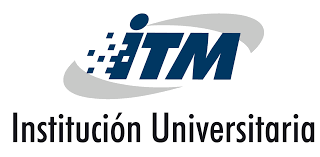

#ITM - Institución Universitaria
#Tema: Procesamiento de Lenguaje Natural - Modelos LLM
#Juan Carlos Briñez de León

#0. Fundamentos

Transformers:

Un Transformer es una arquitectura de redes neuronales propuesta en 2017 en el artículo “Attention is All You Need”.
Se creó inicialmente para tareas de procesamiento de lenguaje natural (NLP), pero hoy es la base de casi todos los modelos modernos: GPT, BERT, Llama, Claude, Gemini, etc.

Su innovación principal es el uso del mecanismo de atención, específicamente self-attention, para procesar secuencias (como texto) sin necesidad de estructuras recurrentes (RNN, LSTM) ni convoluciones.

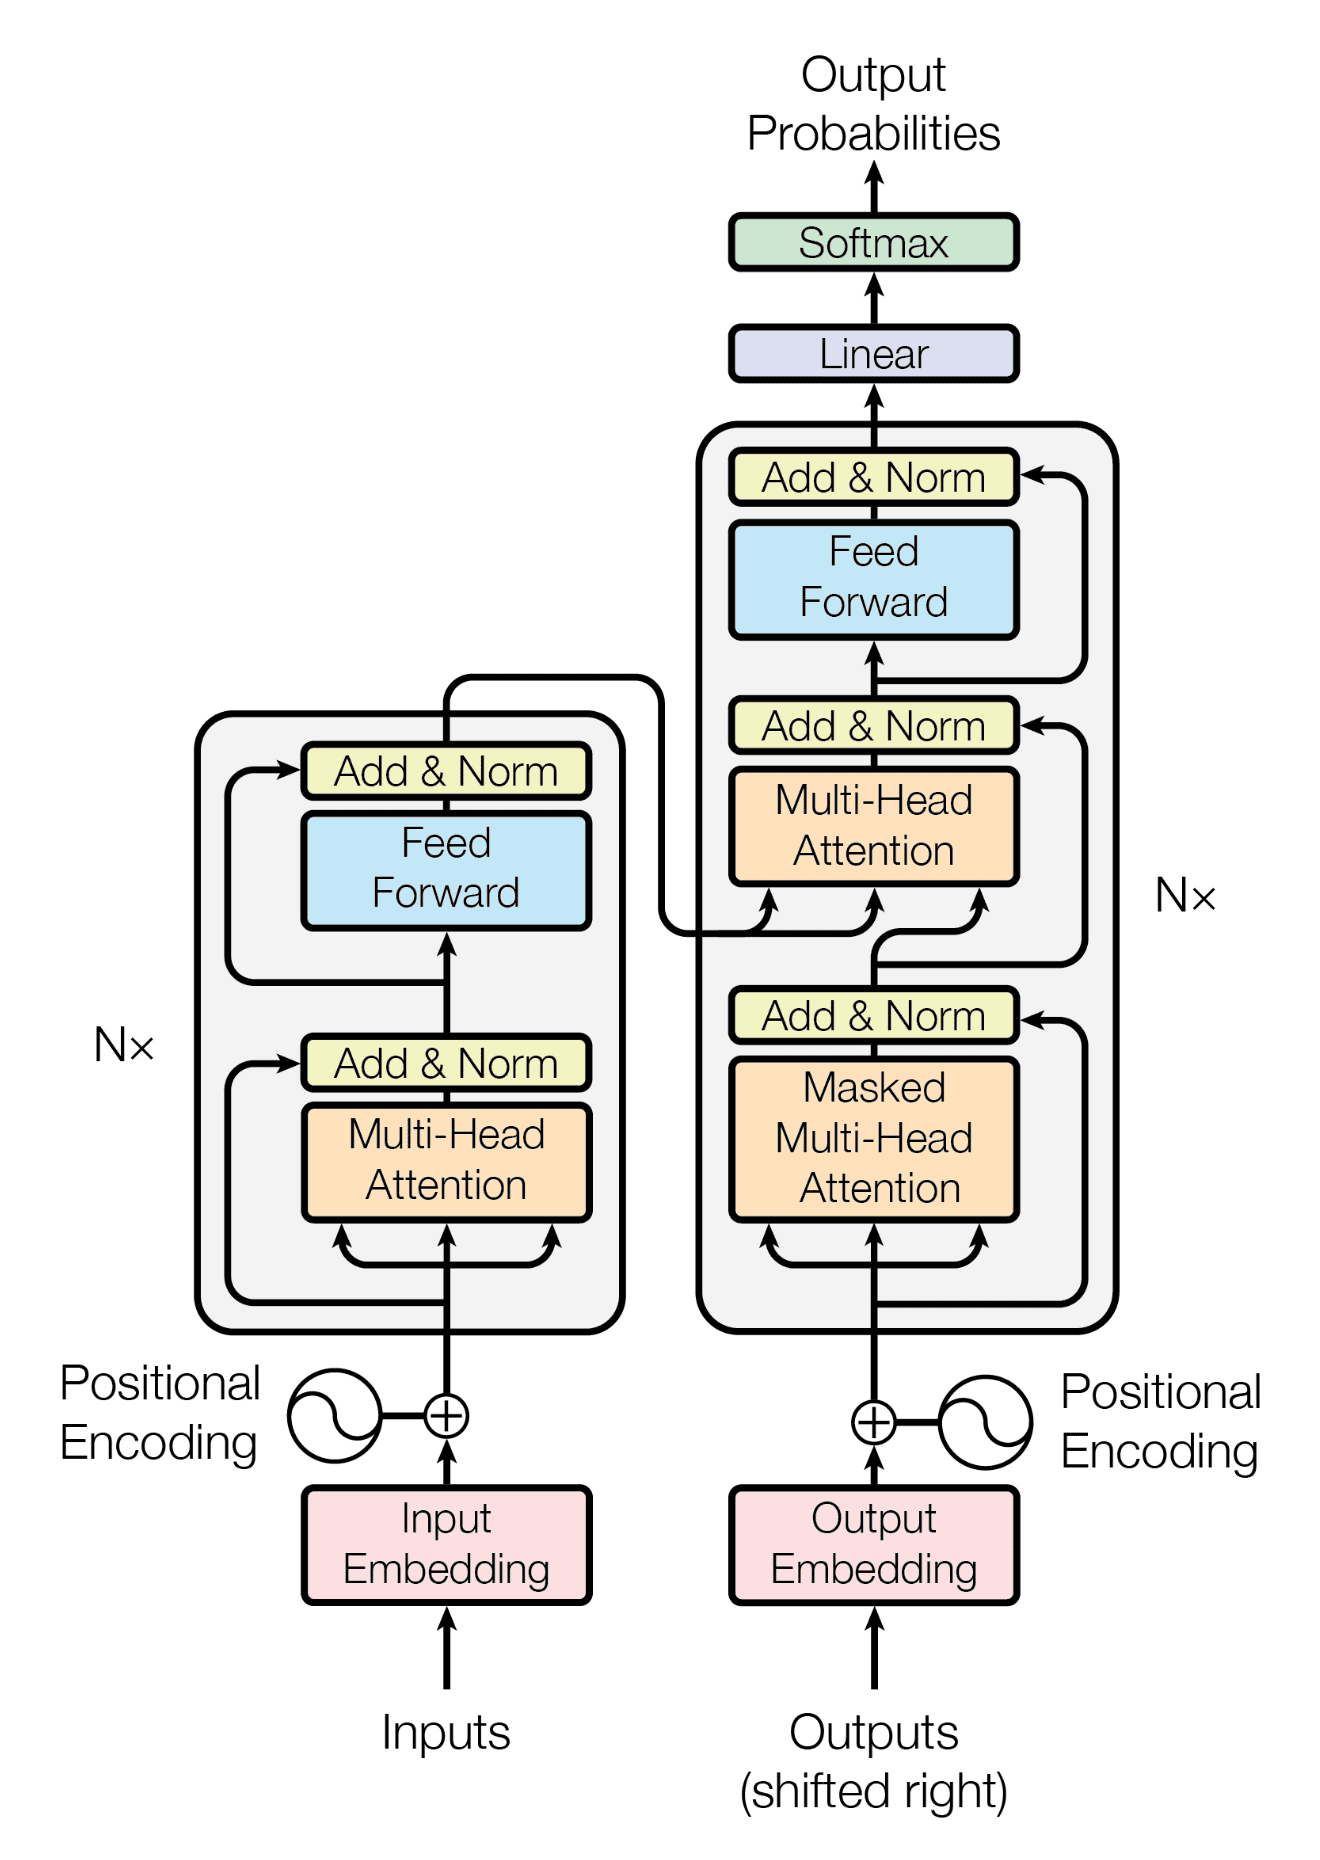

Un Transformer es un modelo que entiende y genera texto mediante un mecanismo de atención que permite que cada palabra mire a todas las demás para captar relaciones y significados complejos.

El texto se convierte en “tokens” (números).
Cada token se transforma en un vector mediante:

Embeddings: representaciones aprendidas del significado.

Positional encodings: información sobre el orden en la secuencia.

Sin esta información, un Transformer no sabría si una palabra va antes o después de otra.

En vez de una sola atención, el Transformer usa varias “cabezas”.
Cada cabeza ve relaciones diferentes:

  - sintácticas

  - semánticas

  - gramaticales

- de largo alcance

Al final, se combinan todas para una representación rica del contexto.

# 1. Instalación de bibliotecas necesarias

Estas bibliotecas permiten usar modelos preentrenados (transformers) y operaciones de red neuronal (torch, es decir, PyTorch).

In [1]:
from google.colab import output
!pip install transformers
!pip install torch
output.clear()
print("Instalación completada")

Instalación completada


 # 2. Carga del modelo de lenguaje (LLM)

Un LLM (Large Language Model) es un modelo de redes neuronales entrenado con grandes cantidades de texto para comprender y generar lenguaje natural. Estos modelos aprenden patrones, relaciones y estilos de escritura a partir de millones de ejemplos.

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

# Elegimos un modelo ligero para usar en Colab sin GPU
model_name = "microsoft/DialoGPT-medium"

# Cargamos el tokenizer y el modelo
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/863M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/863M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

DialoGPT es una variante de GPT-2, ajustada específicamente para tareas conversacionales. Es adecuado para este ejercicio por ser más liviano que GPT-3, y libremente accesible.

# 3. Función de conversación

Codifica el mensaje del usuario.

Añade el historial de conversación para mantener el contexto.

Genera una respuesta con el modelo.

Devuelve la respuesta en texto.

In [3]:
# Variable para guardar el historial de conversación
chat_history_ids = None

def responder_usuario(mensaje_usuario):
    global chat_history_ids

    # 1. Codificar mensaje del usuario
    input_ids = tokenizer.encode(mensaje_usuario + tokenizer.eos_token, return_tensors='pt')

    # 2. Agregar historial anterior si existe
    if chat_history_ids is not None:
        input_ids = torch.cat([chat_history_ids, input_ids], dim=-1)

    # 3. Crear attention_mask para evitar advertencias
    attention_mask = torch.ones(input_ids.shape, dtype=torch.long)

    # 4. Generar respuesta del modelo con sampling para evitar repeticiones
    output_ids = model.generate(
        input_ids,
        max_length=1000,
        pad_token_id=tokenizer.eos_token_id,
        attention_mask=attention_mask,
        do_sample=True,
        top_p=0.92,      # nucleus sampling
        top_k=50,        # restringe a los mejores 50 tokens
        temperature=0.7  # controla la aleatoriedad
    )

    # 5. Guardar historial para mantener el contexto
    chat_history_ids = output_ids

    # 6. Decodificar y retornar la respuesta
    respuesta = tokenizer.decode(output_ids[:, input_ids.shape[-1]:][0], skip_special_tokens=True)
    return respuesta

# 4. Loop de conversación

In [4]:
# @title
import ipywidgets as widgets
from IPython.display import display, clear_output

# Crear elementos de interfaz
input_box = widgets.Text(
    placeholder='Hello, I am sofIA, type your mesagge for starting...',
    description='Tú:',
    layout=widgets.Layout(width='80%')
)

output_area = widgets.Output(layout={'border': '1px solid black'})

boton_enviar = widgets.Button(description="Enviar", button_style='info')
boton_limpiar = widgets.Button(description="Limpiar", button_style='warning')

# Manejar evento de clic
def enviar_mensaje(b):
    mensaje = input_box.value.strip()
    if mensaje:
        with output_area:
            print(f"Tú: {mensaje}")
            respuesta = responder_usuario(mensaje)
            print(f"sofIA: {respuesta}\n")
    input_box.value = ""

def limpiar_chat(b):
    global chat_history_ids
    chat_history_ids = None
    output_area.clear_output()

# Conectar eventos
boton_enviar.on_click(enviar_mensaje)
boton_limpiar.on_click(limpiar_chat)

# Mostrar interfaz
display(input_box, widgets.HBox([boton_enviar, boton_limpiar]), output_area)

Text(value='', description='Tú:', layout=Layout(width='80%'), placeholder='Hello, I am sofIA, type your mesagg…

Output(layout=Layout(border='1px solid black'))

# 5. Información adicional

| Modelo                        | Parámetros     | Tokens de Entrenamiento Estimados                      | Enfoque Principal         | Uso Típico                      |
| ----------------------------- | -------------- | ------------------------------------------------------ | ------------------------- | ------------------------------- |
| **GPT-2 (OpenAI)**            | 124M - 1.5B    | \~40 GB de texto (\~8B tokens)                         | Generación general        | Chat, texto, código             |
| **DialoGPT-medium**           | 345M           | \~147M diálogos Reddit (\~147M turnos = \~500M tokens) | Conversación              | Chatbots simples                |
| **GPT-Neo 1.3B (EleutherAI)** | 1.3B           | \~825 GB (\~300B tokens)                               | General, código           | Asistentes, generación de texto |
| **GPT-J-6B**                  | 6B             | \~825 GB (\~300B tokens)                               | General, código           | Reemplazo abierto de GPT-3      |
| **LLaMA 2 (Meta)**            | 7B / 13B / 70B | \~2T tokens (terabytes de texto)                       | Multilingüe, eficiente    | Investigación, generación       |
| **Mistral 7B**                | 7B             | \~1.5T tokens                                          | Código, instrucciones     | Chat, generación precisa        |
| **Falcon 7B**                 | 7B             | \~1.5T tokens                                          | Eficiencia, diálogo       | Chat, clasificación, resumen    |
| **GPT-3 (OpenAI)**            | 175B           | \~300B tokens                                          | Generación general        | ChatGPT, Codex                  |
| **GPT-4 (OpenAI)**            | \~>500B?\*     | No publicado                                           | Multimodal, instrucciones | Chat, análisis, creación        |


Tokens ≠ palabras: Por ejemplo, "universidad" puede ser un solo token, pero "inteligencia artificial" puede ser tres.

DialoGPT fue afinado a partir de GPT-2 sobre diálogos de Reddit.

GPT-Neo, GPT-J y Falcon son open-source y accesibles para uso académico o comercial.

LLaMA 2 y Mistral han sido entrenados en corpus curados, lo que mejora la calidad sin inflar el tamaño del modelo.

* OpenAI no ha publicado el número exacto de parámetros de GPT-4, pero se estima en cientos de miles de millones.

============================================================

# 6. Un bot en español

In [5]:
!pip install transformers accelerate sentencepiece ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 28.1 MB/s eta 0:00:00


In [6]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model_name = "tiiuae/falcon-7b-instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", torch_dtype=torch.float16)
model.eval()

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/281 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


...

model-00001-of-00002.safetensors:   0%|          | 0.00/9.95G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/4.48G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/117 [00:00<?, ?B/s]

FalconForCausalLM(
  (transformer): FalconModel(
    (word_embeddings): Embedding(65024, 4544)
    (h): ModuleList(
      (0-31): 32 x FalconDecoderLayer(
        (self_attention): FalconAttention(
          (query_key_value): FalconLinear(in_features=4544, out_features=4672, bias=False)
          (dense): FalconLinear(in_features=4544, out_features=4544, bias=False)
          (attention_dropout): Dropout(p=0.0, inplace=False)
        )
        (mlp): FalconMLP(
          (dense_h_to_4h): FalconLinear(in_features=4544, out_features=18176, bias=False)
          (act): GELUActivation()
          (dense_4h_to_h): FalconLinear(in_features=18176, out_features=4544, bias=False)
        )
        (input_layernorm): LayerNorm((4544,), eps=1e-05, elementwise_affine=True)
      )
    )
    (ln_f): LayerNorm((4544,), eps=1e-05, elementwise_affine=True)
    (rotary_emb): FalconRotaryEmbedding()
  )
  (lm_head): Linear(in_features=4544, out_features=65024, bias=False)
)

In [7]:
def generar_respuesta(prompt, max_new_tokens=128):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id,
    )
    texto = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return texto[len(prompt):].strip()

In [8]:
import ipywidgets as widgets
from IPython.display import display, clear_output

historial = ""

input_box = widgets.Text(placeholder="Escribe tu mensaje aquí...", description="Tú:")
output_area = widgets.Output(layout={'border': '1px solid black', 'height': '300px', 'overflow_y': 'auto'})
send_button = widgets.Button(description="Enviar", button_style='success')
clear_button = widgets.Button(description="Limpiar", button_style='warning')

def enviar(b):
    global historial
    mensaje = input_box.value.strip()
    if not mensaje:
        return
    with output_area:
        print(f"Tú: {mensaje}")
    input_box.value = ""
    historial += f"Tú: {mensaje}\nBot: "
    respuesta = generar_respuesta(historial)
    with output_area:
        print(f"Bot: {respuesta}\n")
    historial += f"{respuesta}\n"

def limpiar(b):
    global historial
    historial = ""
    output_area.clear_output()

send_button.on_click(enviar)
clear_button.on_click(limpiar)

display(input_box, widgets.HBox([send_button, clear_button]), output_area)

Text(value='', description='Tú:', placeholder='Escribe tu mensaje aquí...')

Output(layout=Layout(border='1px solid black', height='300px', overflow_y='auto'))

Setting `pad_token_id` to `eos_token_id`:11 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:11 for open-end generation.


#7. Parcial 4